# Prédiction de Volatilité par Machine Learning Classification
## Réponse au feedback : Approche analytique ambitieuse

Au lieu de prédire le prix exact, nous allons entraîner des modèles de classification (XGBoost et Random Forest) pour **prédire les pics de volatilité** basés sur les features de sentiment.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Création du dossier pour les outputs
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"✓ Dossier de sortie créé: {OUTPUT_DIR.absolute()}")

✓ Dossier de sortie créé: C:\Users\ANAS\PycharmProjects\JupyterProject\outputs


## 1. Chargement et Exploration des Données

In [52]:
# Chargement des données
df = pd.read_csv('crypto_sentiment_prediction_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Shape du dataset: {df.shape}")
print(f"\nPremières lignes:")
df.head()

Shape du dataset: (2063, 14)

Premières lignes:


,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
0,2025-06-04 20:36:49,Algorand,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1
1,2025-06-04 20:48:25,Cosmos,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7
2,2025-06-04 21:28:54,Cosmos,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4
3,2025-06-04 21:57:48,Ethereum,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7
4,2025-06-04 22:06:40,Solana,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8


In [53]:
# Informations sur le dataset
print("Informations sur le dataset:")
print(df.info())
print("\nStatistiques descriptives:")
df.describe()

Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2063 entries, 0 to 2062
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 2063 non-null   datetime64[ns]
 1   cryptocurrency            2063 non-null   object        
 2   current_price_usd         2063 non-null   float64       
 3   price_change_24h_percent  2063 non-null   float64       
 4   trading_volume_24h        2063 non-null   float64       
 5   market_cap_usd            2063 non-null   float64       
 6   social_sentiment_score    2063 non-null   float64       
 7   news_sentiment_score      2063 non-null   float64       
 8   news_impact_score         2063 non-null   float64       
 9   social_mentions_count     2063 non-null   int64         
 10  fear_greed_index          2063 non-null   float64       
 11  volatility_index          2063 non-null   float64    

,timestamp,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
count,2063,2063.000000,2063.000000,2.063000e+03,2.063000e+03,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000
mean,2025-06-19 23:28:01.373242624,4260.360520,-0.018042,5.889564e+06,4.568510e+13,0.011158,0.002375,3.688366,1218.317014,50.494910,76.436937,50.501503,77.123413
min,2025-06-04 20:36:49,0.298700,-25.560000,2.060664e+05,5.022090e+07,-1.000000,-1.000000,0.070000,2.000000,0.000000,21.400000,1.400000,55.900000
25%,2025-06-12 08:04:43.500000,1.208650,-5.755000,1.835157e+06,1.113379e+10,-0.197500,-0.202000,2.390000,143.500000,41.400000,60.700000,40.250000,72.650000
50%,2025-06-20 00:10:12,13.344200,0.020000,3.633502e+06,1.255924e+11,0.012000,0.007000,3.670000,409.000000,50.600000,79.000000,50.500000,76.700000
75%,2025-06-27 03:59:34.500000,84.970000,5.755000,7.111602e+06,7.634962e+11,0.215000,0.211500,4.970000,1178.000000,59.400000,100.000000,60.550000,81.100000
max,2025-07-04 19:58:28,51610.923200,27.080000,1.402925e+08,1.009556e+15,1.000000,1.000000,9.530000,35578.000000,100.000000,100.000000,97.100000,100.000000
std,NaN,12603.767442,8.000837,7.451165e+06,1.581473e+14,0.303325,0.308788,1.712072,2501.245623,13.367164,21.245765,15.116517,6.651359


## 2. Analyse de Distribution pour Déterminer le Seuil Optimal

### Approche intelligente multi-critères:
1. **Distribution statistique**: Analyser percentiles et écart-type
2. **Équilibrage des classes**: Éviter un déséquilibre extrême
3. **Pertinence économique**: Mouvements significatifs pour le trading
4. **Analyse par crypto**: Certaines cryptos sont plus volatiles

In [54]:
# Analyse de la distribution des variations de prix
price_changes = df['price_change_24h_percent']

print("=" * 60)
print("ANALYSE STATISTIQUE DES VARIATIONS DE PRIX (24h)")
print("=" * 60)

# Statistiques de base
print(f"\nMoyenne: {price_changes.mean():.2f}%")
print(f"Médiane: {price_changes.median():.2f}%")
print(f"Écart-type: {price_changes.std():.2f}%")
print(f"Min: {price_changes.min():.2f}%")
print(f"Max: {price_changes.max():.2f}%")

# Percentiles
print("\n" + "=" * 60)
print("PERCENTILES")
print("=" * 60)
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = np.percentile(price_changes, p)
    print(f"P{p}: {val:.2f}%")

# Seuils basés sur l'écart-type
mean = price_changes.mean()
std = price_changes.std()
print("\n" + "=" * 60)
print("SEUILS BASÉS SUR L'ÉCART-TYPE")
print("=" * 60)
print(f"1 std: ±{std:.2f}% (68% des données)")
print(f"1.5 std: ±{1.5*std:.2f}% (86% des données)")
print(f"2 std: ±{2*std:.2f}% (95% des données)")

ANALYSE STATISTIQUE DES VARIATIONS DE PRIX (24h)

Moyenne: -0.02%
Médiane: 0.02%
Écart-type: 8.00%
Min: -25.56%
Max: 27.08%

PERCENTILES
P10: -10.53%
P25: -5.75%
P50: 0.02%
P75: 5.76%
P90: 10.31%
P95: 12.91%
P99: 18.07%

SEUILS BASÉS SUR L'ÉCART-TYPE
1 std: ±8.00% (68% des données)
1.5 std: ±12.00% (86% des données)
2 std: ±16.00% (95% des données)


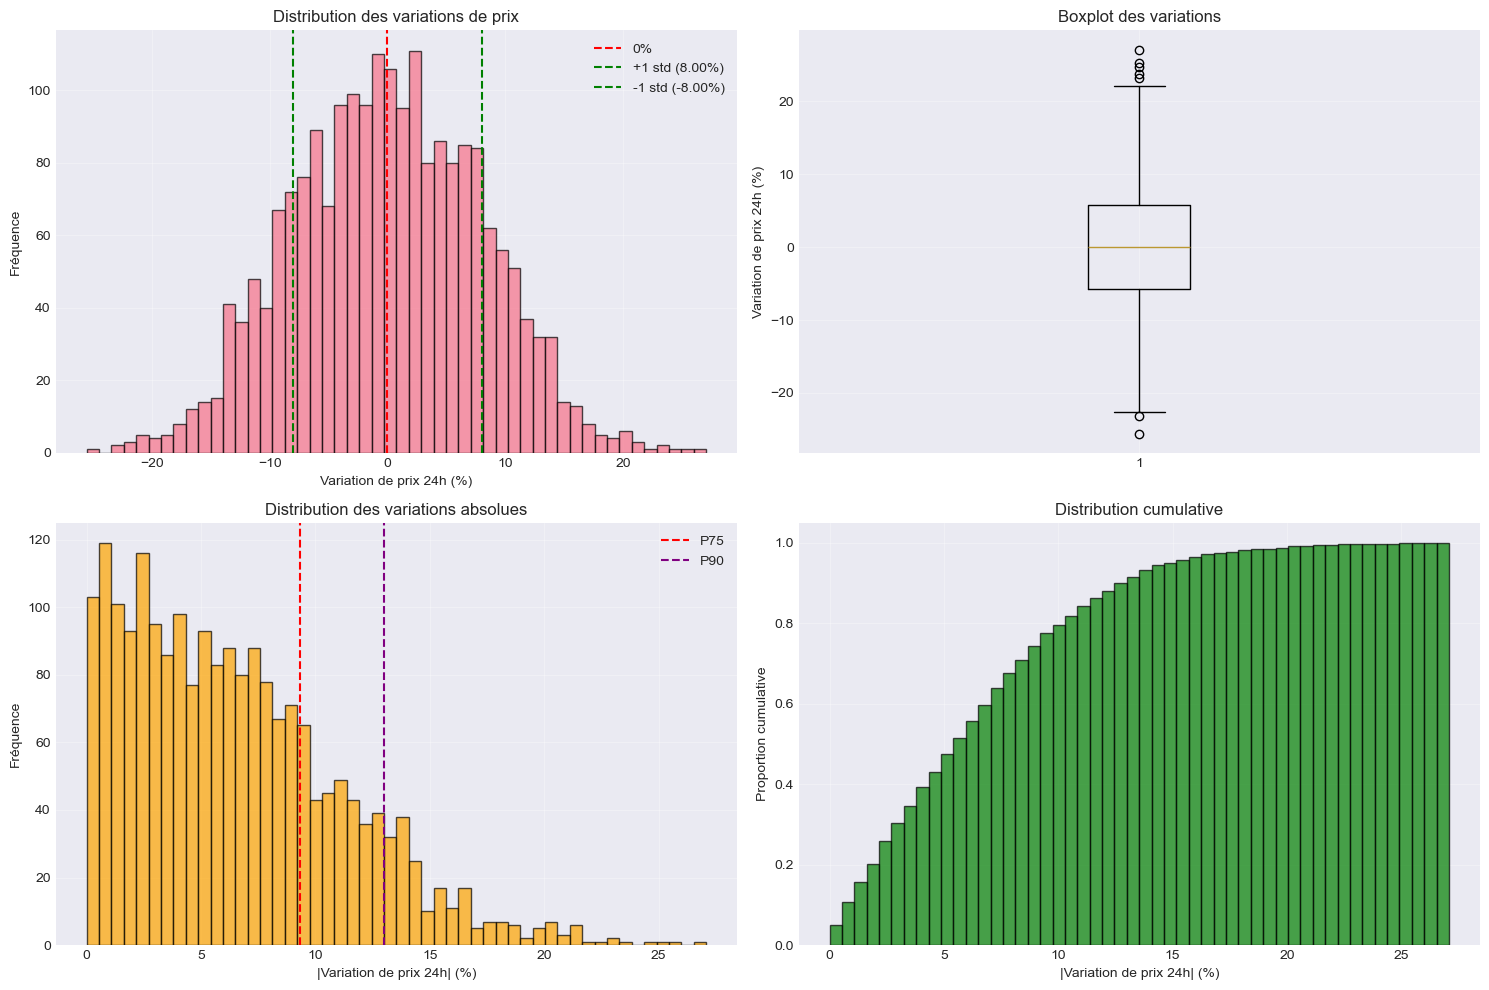

In [55]:
# Visualisation de la distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme
axes[0, 0].hist(price_changes, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', label='0%')
axes[0, 0].axvline(x=std, color='green', linestyle='--', label=f'+1 std ({std:.2f}%)')
axes[0, 0].axvline(x=-std, color='green', linestyle='--', label=f'-1 std ({-std:.2f}%)')
axes[0, 0].set_xlabel('Variation de prix 24h (%)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution des variations de prix')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Boxplot
axes[0, 1].boxplot(price_changes, vert=True)
axes[0, 1].set_ylabel('Variation de prix 24h (%)')
axes[0, 1].set_title('Boxplot des variations')
axes[0, 1].grid(True, alpha=0.3)

# Distribution par valeur absolue
abs_changes = np.abs(price_changes)
axes[1, 0].hist(abs_changes, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].axvline(x=np.percentile(abs_changes, 75), color='red', linestyle='--', label='P75')
axes[1, 0].axvline(x=np.percentile(abs_changes, 90), color='purple', linestyle='--', label='P90')
axes[1, 0].set_xlabel('|Variation de prix 24h| (%)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution des variations absolues')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Distribution cumulative
axes[1, 1].hist(abs_changes, bins=50, cumulative=True, density=True, 
                edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('|Variation de prix 24h| (%)')
axes[1, 1].set_ylabel('Proportion cumulative')
axes[1, 1].set_title('Distribution cumulative')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


VOLATILITÉ PAR CRYPTOMONNAIE
                mean   std  abs_mean  count
cryptocurrency                             
Bitcoin         0.87  8.46      7.03    178
Cosmos          0.51  8.46      6.72    206
Polygon        -0.71  8.25      6.61    217
Cardano        -0.13  8.12      6.67    198
Chainlink      -1.04  8.05      6.56    210
Ethereum        0.19  7.85      6.35    228
Polkadot        0.20  7.85      6.17    204
Algorand       -0.09  7.82      6.25    202
Solana          0.38  7.82      6.35    199
Avalanche      -0.18  7.38      6.18    221


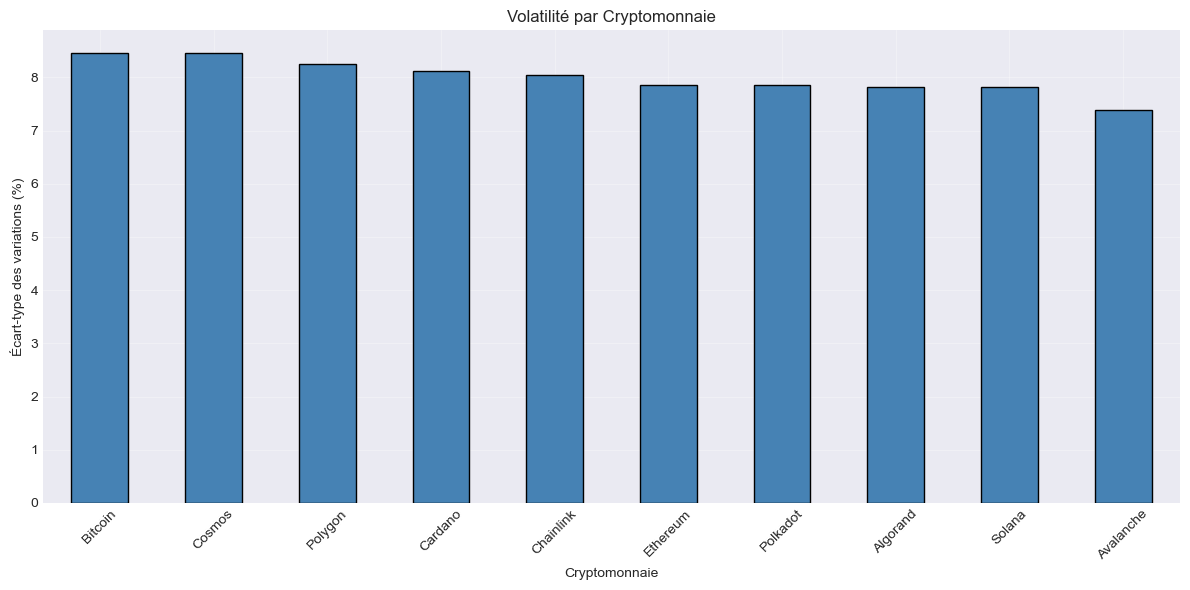

In [56]:
# Analyse par cryptomonnaie
print("\n" + "=" * 60)
print("VOLATILITÉ PAR CRYPTOMONNAIE")
print("=" * 60)

crypto_stats = df.groupby('cryptocurrency')['price_change_24h_percent'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('abs_mean', lambda x: np.abs(x).mean()),
    ('count', 'count')
]).round(2)

crypto_stats = crypto_stats.sort_values('std', ascending=False)
print(crypto_stats)

# Visualisation
plt.figure(figsize=(12, 6))
crypto_stats['std'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Cryptomonnaie')
plt.ylabel('Écart-type des variations (%)')
plt.title('Volatilité par Cryptomonnaie')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
# Test de différents seuils pour l'équilibrage des classes
print("\n" + "=" * 60)
print("ÉQUILIBRAGE DES CLASSES SELON DIFFÉRENTS SEUILS")
print("=" * 60)

test_thresholds = [2, 3, 4, 5, 6, 7, 8, 10]
balance_results = []

for threshold in test_thresholds:
    high_volatility = (np.abs(price_changes) > threshold).sum()
    low_volatility = (np.abs(price_changes) <= threshold).sum()
    total = len(price_changes)
    
    pct_high = (high_volatility / total) * 100
    pct_low = (low_volatility / total) * 100
    ratio = high_volatility / low_volatility if low_volatility > 0 else 0
    
    balance_results.append({
        'Seuil': f'±{threshold}%',
        'Haute Vol': high_volatility,
        '% Haute': f"{pct_high:.1f}%",
        'Basse Vol': low_volatility,
        '% Basse': f"{pct_low:.1f}%",
        'Ratio': f"{ratio:.2f}"
    })

balance_df = pd.DataFrame(balance_results)
print(balance_df.to_string(index=False))

print("\n💡 RECOMMANDATION:")
print("Pour un bon équilibre (20-40% classe minoritaire):")
print("- Seuil conservateur: ±5% (pertinence économique forte)")
print("- Seuil modéré: ±6-7% (équilibre optimal)")
print("- Seuil basé sur stats: ±{:.1f}% (1 écart-type)".format(std))


ÉQUILIBRAGE DES CLASSES SELON DIFFÉRENTS SEUILS
Seuil  Haute Vol % Haute  Basse Vol % Basse Ratio
  ±2%       1684   81.6%        379   18.4%  4.44
  ±3%       1474   71.4%        589   28.6%  2.50
  ±4%       1311   63.5%        752   36.5%  1.74
  ±5%       1150   55.7%        913   44.3%  1.26
  ±6%        991   48.0%       1072   52.0%  0.92
  ±7%        838   40.6%       1225   59.4%  0.68
  ±8%        686   33.3%       1377   66.7%  0.50
 ±10%        442   21.4%       1621   78.6%  0.27

💡 RECOMMANDATION:
Pour un bon équilibre (20-40% classe minoritaire):
- Seuil conservateur: ±5% (pertinence économique forte)
- Seuil modéré: ±6-7% (équilibre optimal)
- Seuil basé sur stats: ±8.0% (1 écart-type)


## 3. Création de la Variable Cible

Nous allons créer plusieurs variables cibles pour comparer:
1. **Volatilité binaire simple**: variation > seuil optimal
2. **Direction + Volatilité**: 3 classes (forte hausse, faible variation, forte baisse)

In [58]:
# Définition du seuil optimal (basé sur l'analyse ci-dessus)
# On choisit un seuil qui donne ~25-35% de la classe minoritaire
THRESHOLD = 6.0  # À ajuster selon vos résultats

print(f"Seuil sélectionné: ±{THRESHOLD}%")
print("=" * 60)

# Variable cible 1: Volatilité binaire
df['high_volatility'] = (np.abs(df['price_change_24h_percent']) > THRESHOLD).astype(int)

# Variable cible 2: Classification ternaire
def classify_movement(change, threshold):
    if change > threshold:
        return 2  # Forte hausse
    elif change < -threshold:
        return 0  # Forte baisse
    else:
        return 1  # Faible variation

df['price_movement'] = df['price_change_24h_percent'].apply(
    lambda x: classify_movement(x, THRESHOLD)
)

# Statistiques des classes
print("\nDistribution - Volatilité Binaire:")
print(df['high_volatility'].value_counts().sort_index())
print(f"\nProportions:")
print(df['high_volatility'].value_counts(normalize=True).sort_index())

print("\n" + "=" * 60)
print("\nDistribution - Mouvement de Prix (3 classes):")
movement_labels = {0: 'Forte Baisse', 1: 'Faible Variation', 2: 'Forte Hausse'}
print(df['price_movement'].value_counts().sort_index().rename(movement_labels))
print(f"\nProportions:")
print(df['price_movement'].value_counts(normalize=True).sort_index().rename(movement_labels))

Seuil sélectionné: ±6.0%

Distribution - Volatilité Binaire:
high_volatility
0    1072
1     991
Name: count, dtype: int64

Proportions:
high_volatility
0    0.519632
1    0.480368
Name: proportion, dtype: float64


Distribution - Mouvement de Prix (3 classes):
price_movement
Forte Baisse         491
Faible Variation    1072
Forte Hausse         500
Name: count, dtype: int64

Proportions:
price_movement
Forte Baisse        0.238003
Faible Variation    0.519632
Forte Hausse        0.242365
Name: proportion, dtype: float64


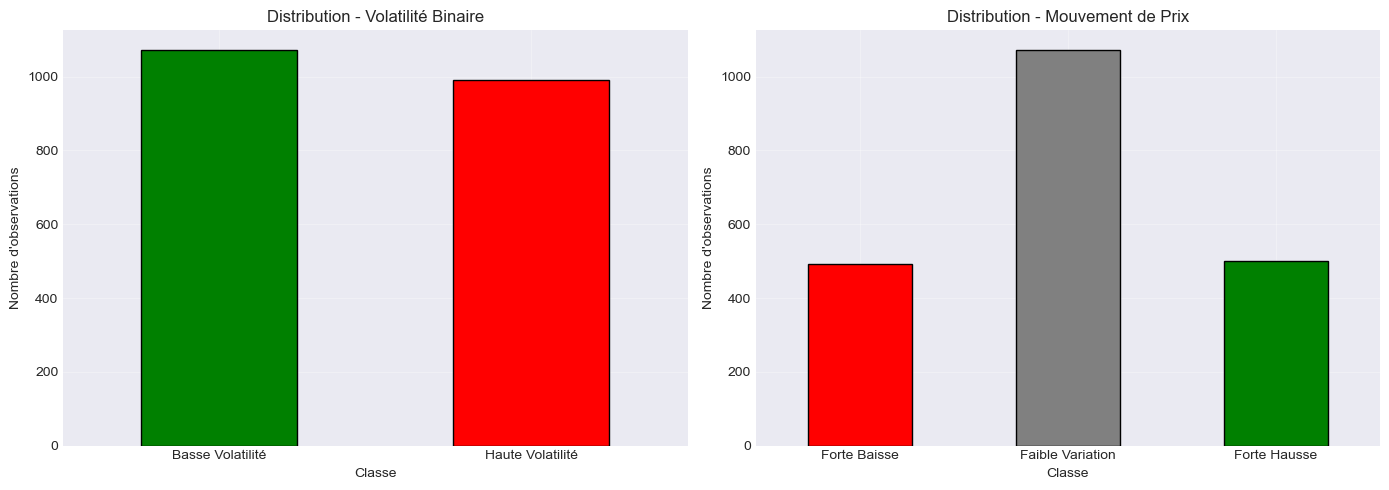

In [59]:
# Visualisation des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volatilité binaire
df['high_volatility'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['green', 'red'], edgecolor='black'
)
axes[0].set_title('Distribution - Volatilité Binaire')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'observations')
axes[0].set_xticklabels(['Basse Volatilité', 'Haute Volatilité'], rotation=0)
axes[0].grid(True, alpha=0.3)

# Mouvement de prix
df['price_movement'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['red', 'gray', 'green'], edgecolor='black'
)
axes[1].set_title('Distribution - Mouvement de Prix')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre d\'observations')
axes[1].set_xticklabels(['Forte Baisse', 'Faible Variation', 'Forte Hausse'], rotation=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Préparation des Features

Nous allons utiliser les features de sentiment et techniques disponibles.

In [60]:
# Sélection des features pertinentes
# Removed: 'volatility_index' (concurrent leak — directly measures what we're predicting)
# Removed: 'prediction_confidence' (pre-computed score likely derived from the target)
feature_cols = [
    'social_sentiment_score',
    'news_sentiment_score',
    'news_impact_score',
    'social_mentions_count',
    'fear_greed_index',
    'rsi_technical_indicator',
    'trading_volume_24h',
]

# Création de features supplémentaires
df['sentiment_composite'] = (df['social_sentiment_score'] + df['news_sentiment_score']) / 2
df['sentiment_divergence'] = abs(df['social_sentiment_score'] - df['news_sentiment_score'])
df['volume_normalized'] = np.log1p(df['trading_volume_24h'])  # Log transform pour normaliser

feature_cols.extend(['sentiment_composite', 'sentiment_divergence', 'volume_normalized'])

print(f"Nombre de features: {len(feature_cols)}")
print(f"\nFeatures utilisées:")
for i, feat in enumerate(feature_cols, 1):
    print(f"{i:2d}. {feat}")

Nombre de features: 10

Features utilisées:
 1. social_sentiment_score
 2. news_sentiment_score
 3. news_impact_score
 4. social_mentions_count
 5. fear_greed_index
 6. rsi_technical_indicator
 7. trading_volume_24h
 8. sentiment_composite
 9. sentiment_divergence
10. volume_normalized



Valeurs manquantes:
Aucune valeur manquante!


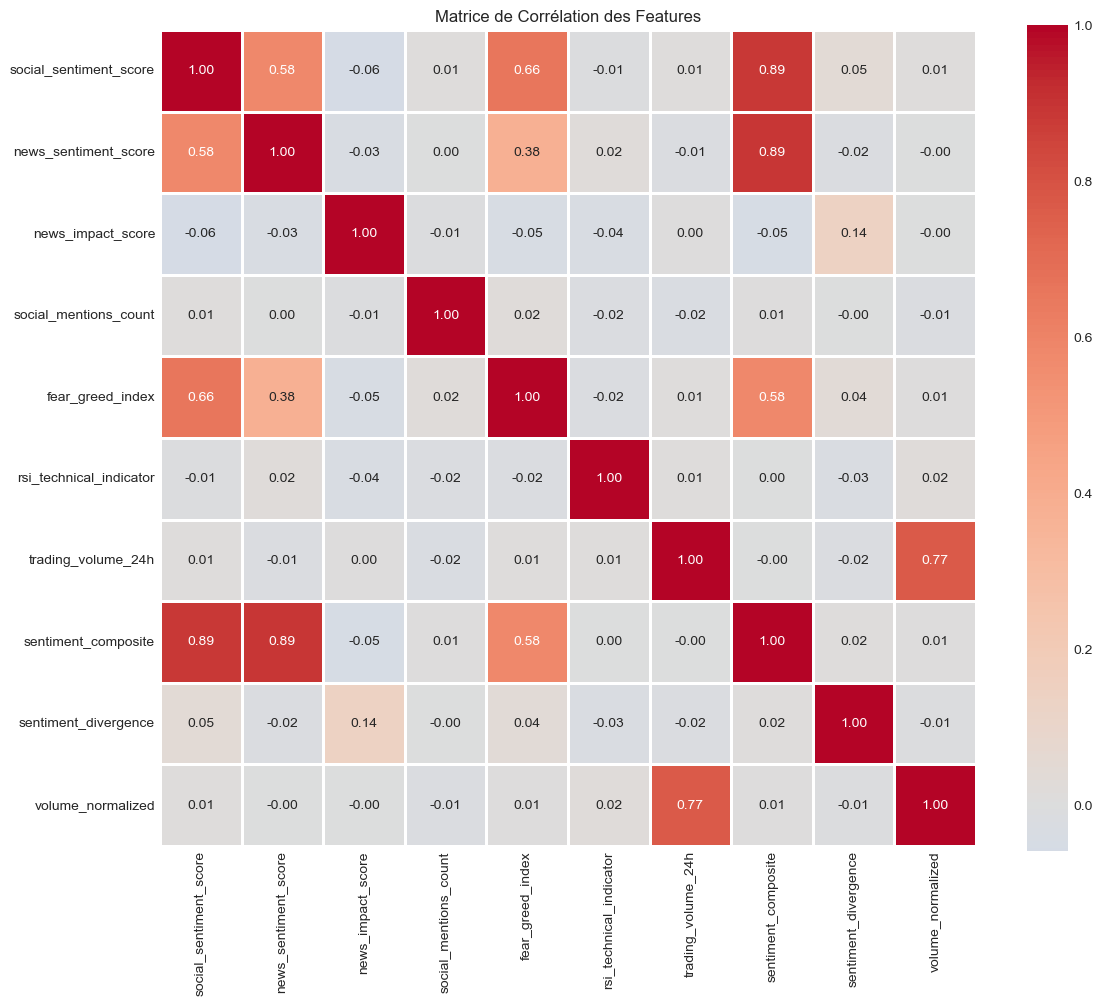

In [61]:
# Vérification des valeurs manquantes
print("\nValeurs manquantes:")
missing = df[feature_cols].isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Aucune valeur manquante!")

# Matrice de corrélation
plt.figure(figsize=(12, 10))
correlation_matrix = df[feature_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Matrice de Corrélation des Features')
plt.tight_layout()
plt.show()

## 5. Entraînement des Modèles - Volatilité Binaire

In [62]:
# Préparation des données
X = df[feature_cols].copy()
y = df['high_volatility'].copy()

# Split train/test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille du train: {X_train.shape}")
print(f"Taille du test: {X_test.shape}")
print(f"\nDistribution train:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribution test:")
print(y_test.value_counts(normalize=True))

Taille du train: (1650, 10)
Taille du test: (413, 10)

Distribution train:
high_volatility
0    0.519394
1    0.480606
Name: proportion, dtype: float64

Distribution test:
high_volatility
0    0.520581
1    0.479419
Name: proportion, dtype: float64


In [63]:
# Normalisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversion en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

### 5.1 Random Forest

In [64]:
print("=" * 60)
print("ENTRAÎNEMENT RANDOM FOREST")
print("=" * 60)

# Modèle Random Forest avec paramètres optimisés
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  # Important pour gérer le déséquilibre
    random_state=42,
    n_jobs=-1
)

# Entraînement
rf_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n✓ Entraînement terminé!")

ENTRAÎNEMENT RANDOM FOREST

✓ Entraînement terminé!



RÉSULTATS RANDOM FOREST

Cross-validation ROC-AUC: 0.5051 (+/- 0.0241)

ROC-AUC (test): 0.4811

Classification Report:
                  precision    recall  f1-score   support

Basse Volatilité       0.51      0.54      0.53       215
Haute Volatilité       0.46      0.43      0.45       198

        accuracy                           0.49       413
       macro avg       0.49      0.49      0.49       413
    weighted avg       0.49      0.49      0.49       413



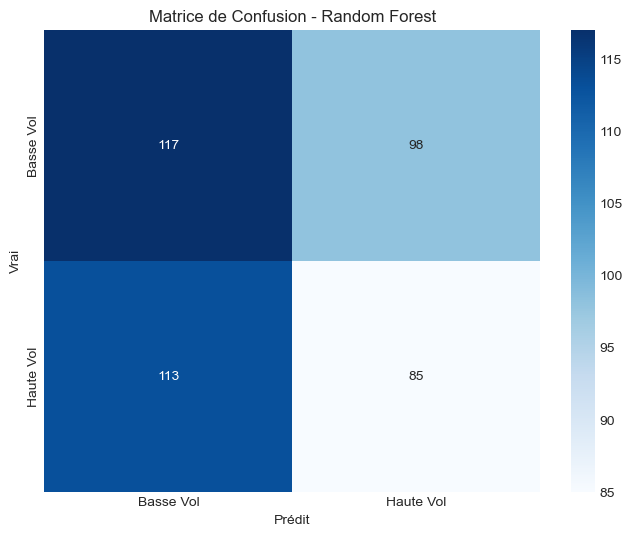

In [65]:
from sklearn.pipeline import Pipeline

# Évaluation Random Forest
print("\n" + "=" * 60)
print("RÉSULTATS RANDOM FOREST")
print("=" * 60)

# Cross-validation avec Pipeline: le scaler est fit uniquement sur le fold d'entraînement
# évite la fuite de données (data leakage) vers les folds de validation
rf_pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
cv_scores = cross_val_score(rf_pipeline_cv, X_train, y_train,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                            scoring='roc_auc')
print(f"\nCross-validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Métriques sur le test set (utilise rf_model entraîné sur X_train_scaled)
print(f"\nROC-AUC (test): {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                          target_names=['Basse Volatilité', 'Haute Volatilité']))

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Basse Vol', 'Haute Vol'],
            yticklabels=['Basse Vol', 'Haute Vol'])
plt.title('Matrice de Confusion - Random Forest')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

### 5.2 XGBoost

In [66]:
print("=" * 60)
print("ENTRAÎNEMENT XGBOOST")
print("=" * 60)

# Calcul du scale_pos_weight pour gérer le déséquilibre
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Modèle XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# Entraînement
xgb_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n✓ Entraînement terminé!")

ENTRAÎNEMENT XGBOOST

✓ Entraînement terminé!



RÉSULTATS XGBOOST

Cross-validation ROC-AUC: 0.5171 (+/- 0.0257)

ROC-AUC (test): 0.4876

Classification Report:
                  precision    recall  f1-score   support

Basse Volatilité       0.49      0.48      0.49       215
Haute Volatilité       0.45      0.45      0.45       198

        accuracy                           0.47       413
       macro avg       0.47      0.47      0.47       413
    weighted avg       0.47      0.47      0.47       413



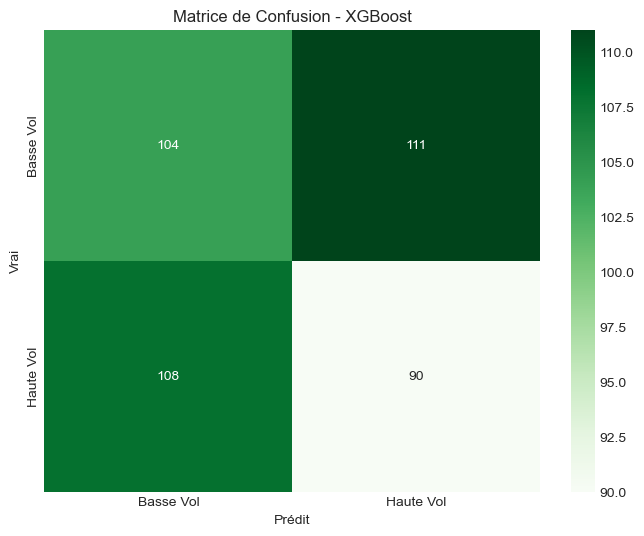

In [67]:
# Évaluation XGBoost
print("\n" + "=" * 60)
print("RÉSULTATS XGBOOST")
print("=" * 60)

# Cross-validation avec Pipeline pour éviter la fuite de données
xgb_pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])
cv_scores_xgb = cross_val_score(xgb_pipeline_cv, X_train, y_train,
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='roc_auc')
print(f"\nCross-validation ROC-AUC: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

# Métriques sur le test set (utilise xgb_model entraîné sur X_train_scaled)
print(f"\nROC-AUC (test): {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
                          target_names=['Basse Volatilité', 'Haute Volatilité']))

# Matrice de confusion
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Basse Vol', 'Haute Vol'],
            yticklabels=['Basse Vol', 'Haute Vol'])
plt.title('Matrice de Confusion - XGBoost')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

### 5.3 Comparaison des Modèles

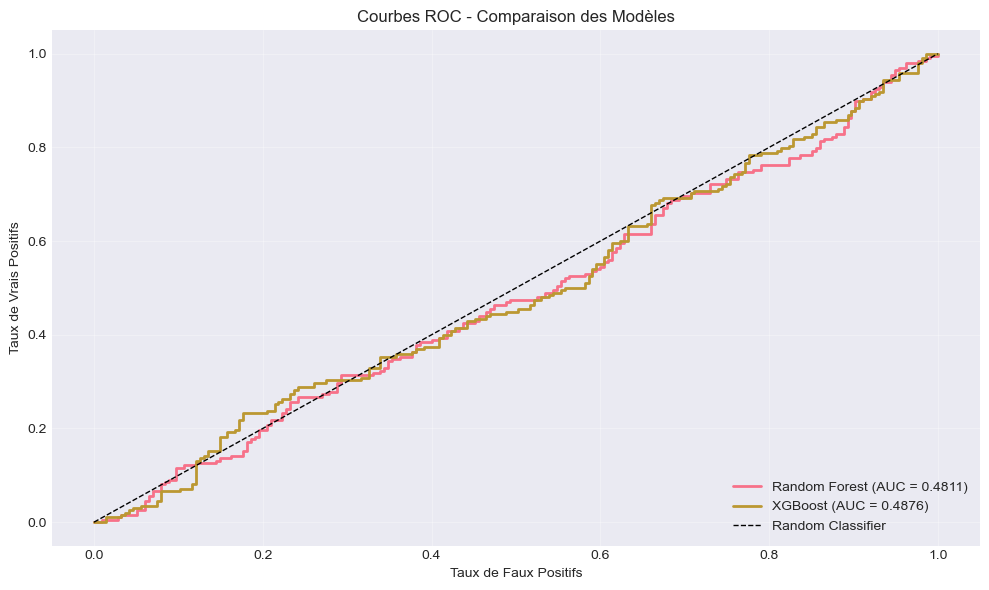


COMPARAISON DES MODÈLES
       Modèle  ROC-AUC  CV ROC-AUC   CV Std
Random Forest 0.481113    0.505091 0.024068
      XGBoost 0.487644    0.517083 0.025663

🏆 Meilleur modèle: XGBoost


In [68]:
# Courbes ROC
plt.figure(figsize=(10, 6))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)

# Ligne diagonale
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbes ROC - Comparaison des Modèles')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tableau comparatif
comparison = pd.DataFrame({
    'Modèle': ['Random Forest', 'XGBoost'],
    'ROC-AUC': [auc_rf, auc_xgb],
    'CV ROC-AUC': [cv_scores.mean(), cv_scores_xgb.mean()],
    'CV Std': [cv_scores.std(), cv_scores_xgb.std()]
})

print("\n" + "=" * 60)
print("COMPARAISON DES MODÈLES")
print("=" * 60)
print(comparison.to_string(index=False))

best_model_name = comparison.loc[comparison['ROC-AUC'].idxmax(), 'Modèle']
print(f"\n🏆 Meilleur modèle: {best_model_name}")

## 6. Analyse de l'Importance des Features

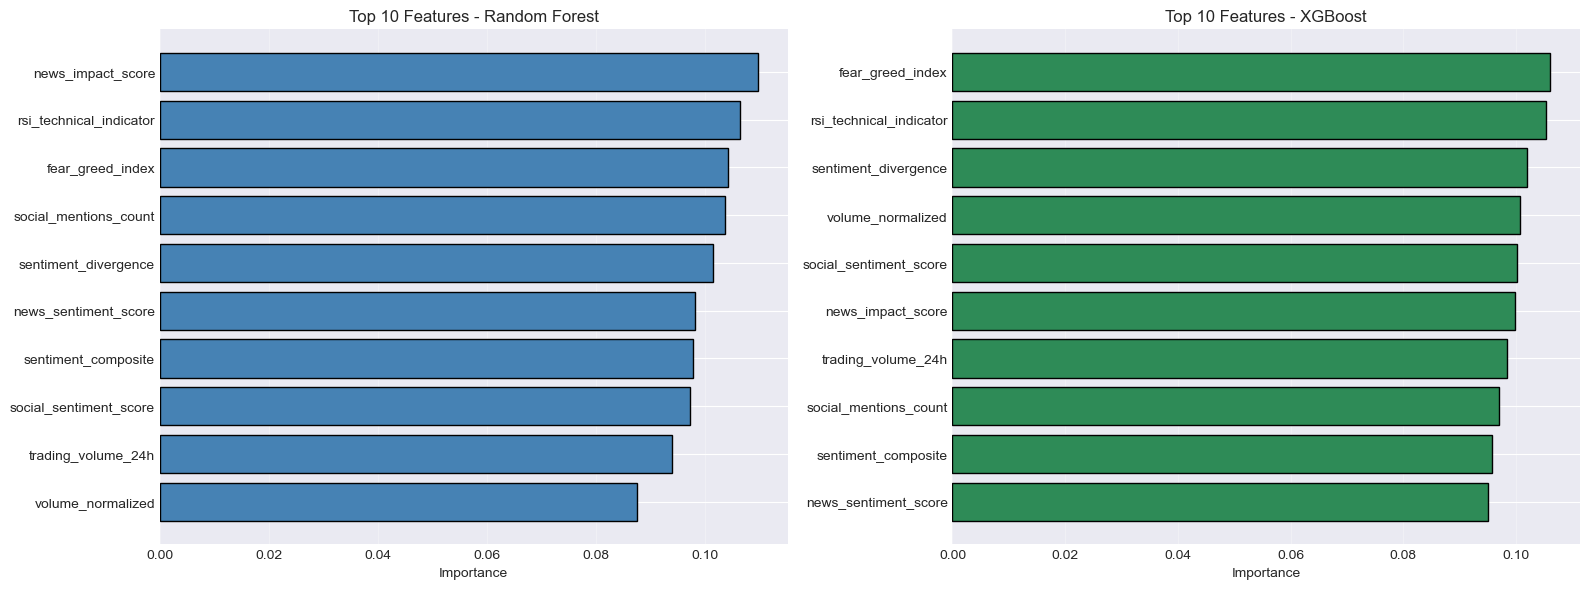


Top 10 Features - Random Forest:
                feature  importance
      news_impact_score    0.109647
rsi_technical_indicator    0.106353
       fear_greed_index    0.104181
  social_mentions_count    0.103685
   sentiment_divergence    0.101377
   news_sentiment_score    0.098236
    sentiment_composite    0.097774
 social_sentiment_score    0.097212
     trading_volume_24h    0.094027
      volume_normalized    0.087509

Top 10 Features - XGBoost:
                feature  importance
       fear_greed_index    0.106040
rsi_technical_indicator    0.105289
   sentiment_divergence    0.101872
      volume_normalized    0.100698
 social_sentiment_score    0.100172
      news_impact_score    0.099771
     trading_volume_24h    0.098404
  social_mentions_count    0.097026
    sentiment_composite    0.095653
   news_sentiment_score    0.095075


In [69]:
# Feature importance pour les deux modèles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

axes[0].barh(rf_importance['feature'][:10], rf_importance['importance'][:10], 
             color='steelblue', edgecolor='black')
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 10 Features - Random Forest')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# XGBoost
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(xgb_importance['feature'][:10], xgb_importance['importance'][:10],
             color='seagreen', edgecolor='black')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 10 Features - XGBoost')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nTop 10 Features - Random Forest:")
print(rf_importance[:10].to_string(index=False))

print("\nTop 10 Features - XGBoost:")
print(xgb_importance[:10].to_string(index=False))

## 7. Analyse des Faux Positifs et Faux Négatifs

In [70]:
# Utilisons le meilleur modèle pour l'analyse
best_model = xgb_model if auc_xgb > auc_rf else rf_model
y_pred_best = y_pred_xgb if auc_xgb > auc_rf else y_pred_rf
y_pred_proba_best = y_pred_proba_xgb if auc_xgb > auc_rf else y_pred_proba_rf

# Identification des erreurs
test_results = X_test.copy()
test_results['y_true'] = y_test
test_results['y_pred'] = y_pred_best
test_results['y_pred_proba'] = y_pred_proba_best
test_results['actual_change'] = df.loc[X_test.index, 'price_change_24h_percent']
test_results['crypto'] = df.loc[X_test.index, 'cryptocurrency']

# Faux positifs et faux négatifs
false_positives = test_results[(test_results['y_true'] == 0) & (test_results['y_pred'] == 1)]
false_negatives = test_results[(test_results['y_true'] == 1) & (test_results['y_pred'] == 0)]

print("=" * 60)
print("ANALYSE DES ERREURS")
print("=" * 60)
print(f"\nFaux Positifs: {len(false_positives)} ({len(false_positives)/len(test_results)*100:.1f}%)")
print(f"Faux Négatifs: {len(false_negatives)} ({len(false_negatives)/len(test_results)*100:.1f}%)")

if len(false_positives) > 0:
    print("\nCaractéristiques moyennes des Faux Positifs:")
    print(f"Variation réelle moyenne: {false_positives['actual_change'].mean():.2f}%")
    print(f"Fear & Greed moyen: {false_positives['fear_greed_index'].mean():.2f}")
    print(f"Sentiment social moyen: {false_positives['social_sentiment_score'].mean():.3f}")

if len(false_negatives) > 0:
    print("\nCaractéristiques moyennes des Faux Négatifs:")
    print(f"Variation réelle moyenne: {false_negatives['actual_change'].mean():.2f}%")
    print(f"Fear & Greed moyen: {false_negatives['fear_greed_index'].mean():.2f}")
    print(f"Sentiment social moyen: {false_negatives['social_sentiment_score'].mean():.3f}")

ANALYSE DES ERREURS

Faux Positifs: 111 (26.9%)
Faux Négatifs: 108 (26.2%)

Caractéristiques moyennes des Faux Positifs:
Variation réelle moyenne: 0.13%
Fear & Greed moyen: 50.88
Sentiment social moyen: -0.011

Caractéristiques moyennes des Faux Négatifs:
Variation réelle moyenne: 0.87%
Fear & Greed moyen: 52.34
Sentiment social moyen: 0.063


## 7.5 Performance par Cryptomonnaie

Analysons comment le modèle performe sur chaque cryptomonnaie individuellement.

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcul des métriques par cryptomonnaie
print("=" * 80)
print("PERFORMANCE DU MODÈLE PAR CRYPTOMONNAIE")
print("=" * 80)

crypto_performance = []

for crypto in sorted(test_results['crypto'].unique()):
    crypto_data = test_results[test_results['crypto'] == crypto]
    
    if len(crypto_data) < 5:  # Skip si pas assez de données
        continue
    
    y_true_crypto = crypto_data['y_true']
    y_pred_crypto = crypto_data['y_pred']
    y_prob_crypto = crypto_data['y_pred_proba']
    
    # Calcul des métriques
    accuracy = accuracy_score(y_true_crypto, y_pred_crypto)
    
    # Gérer les cas où il n'y a qu'une seule classe
    try:
        precision = precision_score(y_true_crypto, y_pred_crypto, zero_division=0)
        recall = recall_score(y_true_crypto, y_pred_crypto, zero_division=0)
        f1 = f1_score(y_true_crypto, y_pred_crypto, zero_division=0)
        
        # ROC-AUC uniquement si les deux classes sont présentes
        if len(y_true_crypto.unique()) > 1:
            roc_auc = roc_auc_score(y_true_crypto, y_prob_crypto)
        else:
            roc_auc = np.nan
    except:
        precision = recall = f1 = roc_auc = np.nan
    
    crypto_performance.append({
        'Crypto': crypto,
        'Samples': len(crypto_data),
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'High_Vol_%': (y_true_crypto == 1).mean() * 100
    })

# Créer DataFrame
perf_df = pd.DataFrame(crypto_performance)
perf_df = perf_df.sort_values('F1-Score', ascending=False)

print(f"\nNombre de cryptomonnaies dans le test set: {len(perf_df)}")
print(f"\nMétriques par cryptomonnaie (triées par F1-Score):")
print("=" * 80)

# Afficher le tableau
display_df = perf_df.copy()
display_df['Accuracy'] = display_df['Accuracy'].apply(lambda x: f"{x:.3f}")
display_df['Precision'] = display_df['Precision'].apply(lambda x: f"{x:.3f}" if not pd.isna(x) else "N/A")
display_df['Recall'] = display_df['Recall'].apply(lambda x: f"{x:.3f}" if not pd.isna(x) else "N/A")
display_df['F1-Score'] = display_df['F1-Score'].apply(lambda x: f"{x:.3f}" if not pd.isna(x) else "N/A")
display_df['ROC-AUC'] = display_df['ROC-AUC'].apply(lambda x: f"{x:.3f}" if not pd.isna(x) else "N/A")
display_df['High_Vol_%'] = display_df['High_Vol_%'].apply(lambda x: f"{x:.1f}%")

print(display_df.to_string(index=False))

# Statistiques globales
print(f"\n" + "=" * 80)
print("STATISTIQUES AGRÉGÉES")
print("=" * 80)
print(f"Accuracy moyenne: {perf_df['Accuracy'].mean():.3f} (±{perf_df['Accuracy'].std():.3f})")
print(f"Precision moyenne: {perf_df['Precision'].mean():.3f} (±{perf_df['Precision'].std():.3f})")
print(f"Recall moyenne: {perf_df['Recall'].mean():.3f} (±{perf_df['Recall'].std():.3f})")
print(f"F1-Score moyenne: {perf_df['F1-Score'].mean():.3f} (±{perf_df['F1-Score'].std():.3f})")
print(f"ROC-AUC moyenne: {perf_df['ROC-AUC'].mean():.3f} (±{perf_df['ROC-AUC'].std():.3f})")

PERFORMANCE DU MODÈLE PAR CRYPTOMONNAIE

Nombre de cryptomonnaies dans le test set: 10

Métriques par cryptomonnaie (triées par F1-Score):
   Crypto  Samples Accuracy Precision Recall F1-Score ROC-AUC High_Vol_%
 Ethereum       43    0.605     0.550  0.579    0.564   0.647      44.2%
Chainlink       54    0.537     0.484  0.625    0.545   0.542      44.4%
  Bitcoin       29    0.517     0.500  0.500    0.500   0.510      48.3%
   Solana       46    0.478     0.478  0.478    0.478   0.520      50.0%
  Cardano       38    0.447     0.474  0.450    0.462   0.506      52.6%
  Polygon       33    0.485     0.389  0.538    0.452   0.458      39.4%
 Algorand       41    0.488     0.400  0.471    0.432   0.498      41.5%
   Cosmos       42    0.381     0.471  0.320    0.381   0.329      59.5%
Avalanche       46    0.370     0.444  0.296    0.356   0.415      58.7%
 Polkadot       41    0.390     0.286  0.375    0.324   0.473      39.0%

STATISTIQUES AGRÉGÉES
Accuracy moyenne: 0.470 (±0.075)
Pr

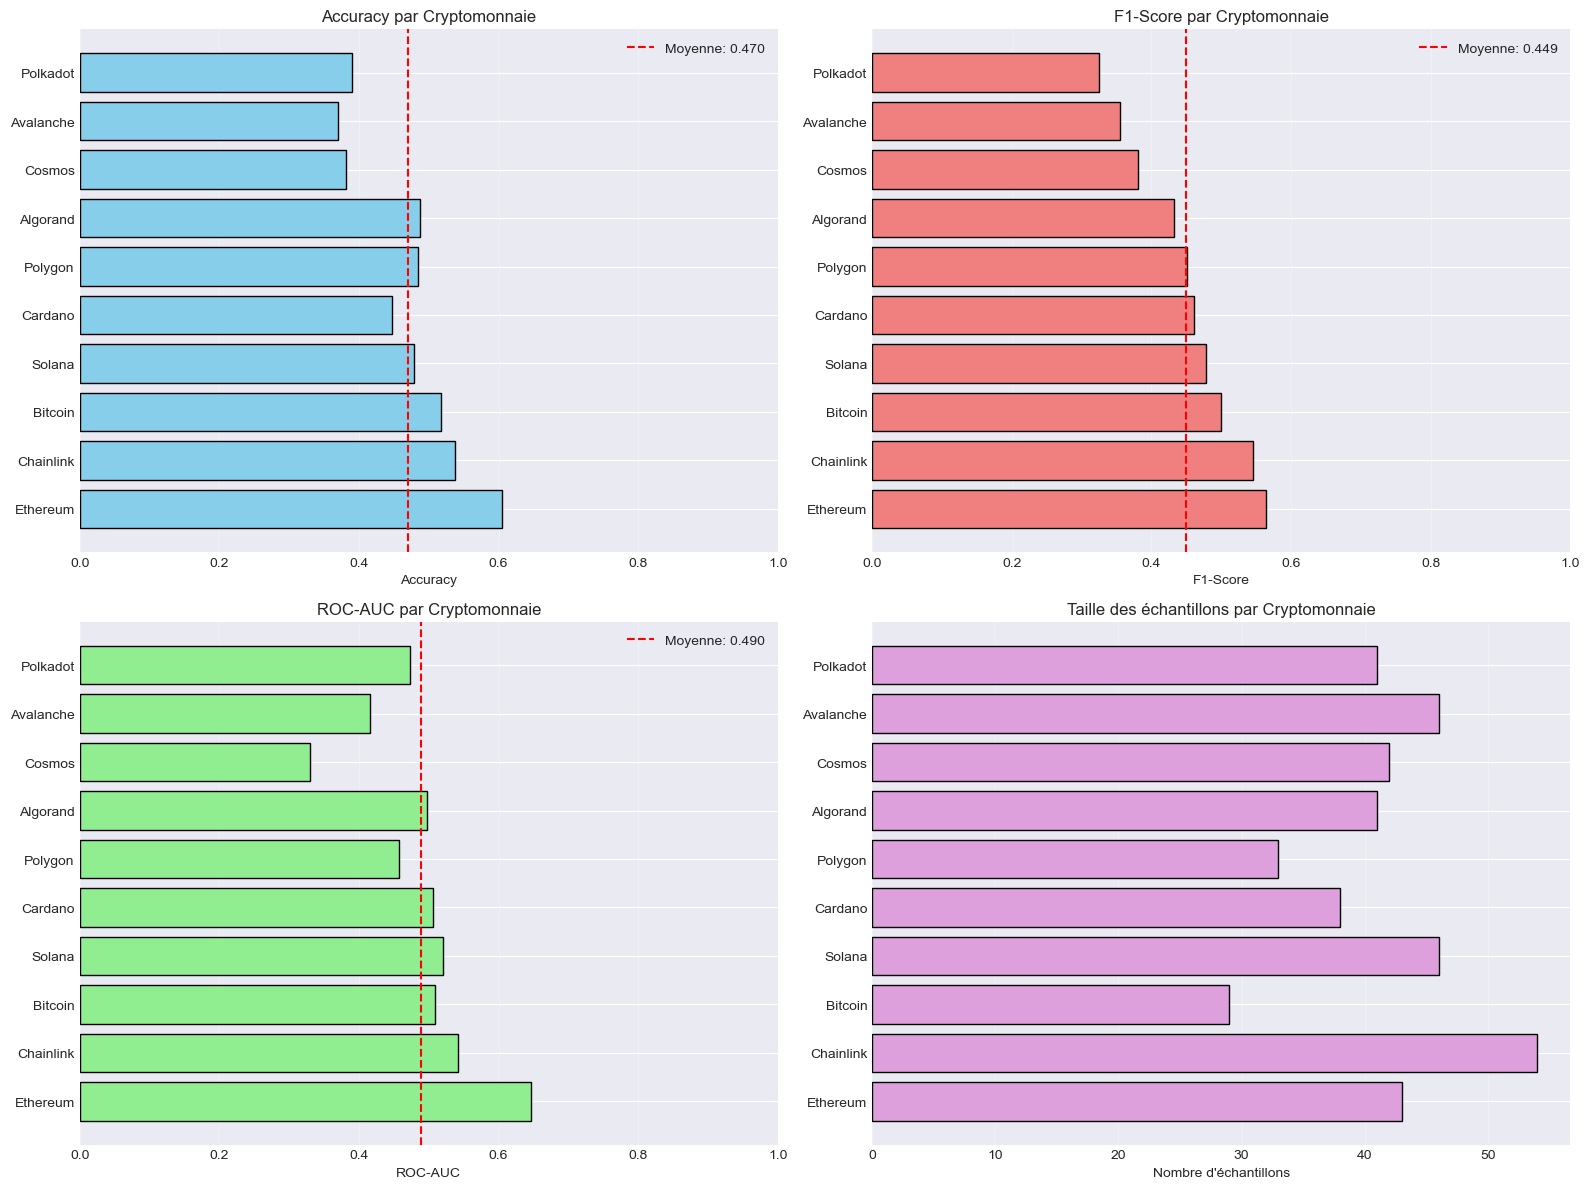


✓ Graphique sauvegardé: outputs\per_crypto_performance.png


In [72]:
# Visualisations des performances par crypto
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy par crypto
axes[0, 0].barh(perf_df['Crypto'], perf_df['Accuracy'], color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Accuracy par Cryptomonnaie')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].axvline(x=perf_df['Accuracy'].mean(), color='red', linestyle='--', 
                   label=f'Moyenne: {perf_df["Accuracy"].mean():.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. F1-Score par crypto
axes[0, 1].barh(perf_df['Crypto'], perf_df['F1-Score'], color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('F1-Score par Cryptomonnaie')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].axvline(x=perf_df['F1-Score'].mean(), color='red', linestyle='--',
                   label=f'Moyenne: {perf_df["F1-Score"].mean():.3f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. ROC-AUC par crypto
valid_roc = perf_df[~perf_df['ROC-AUC'].isna()]
axes[1, 0].barh(valid_roc['Crypto'], valid_roc['ROC-AUC'], color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC par Cryptomonnaie')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].axvline(x=valid_roc['ROC-AUC'].mean(), color='red', linestyle='--',
                   label=f'Moyenne: {valid_roc["ROC-AUC"].mean():.3f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Nombre d'échantillons par crypto
axes[1, 1].barh(perf_df['Crypto'], perf_df['Samples'], color='plum', edgecolor='black')
axes[1, 1].set_xlabel('Nombre d\'échantillons')
axes[1, 1].set_title('Taille des échantillons par Cryptomonnaie')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_crypto_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Graphique sauvegardé: {OUTPUT_DIR / 'per_crypto_performance.png'}")

In [73]:
# Sauvegarder les performances par crypto dans un fichier CSV
crypto_perf_path = OUTPUT_DIR / 'crypto_performance.csv'
perf_df.to_csv(crypto_perf_path, index=False)

print("=" * 80)
print("✓ PERFORMANCE PAR CRYPTO SAUVEGARDÉE")
print("=" * 80)
print(f"Fichier: {crypto_perf_path.name}")
print(f"Chemin: {crypto_perf_path.absolute()}")

# Identifier les cryptos les plus et moins performantes
best_crypto = perf_df.iloc[0]
worst_crypto = perf_df.iloc[-1]

print(f"\n" + "=" * 80)
print("MEILLEURES ET PIRES PERFORMANCES")
print("=" * 80)

# Function to safely format numbers or return N/A
fmt = lambda x: f"{x:.3f}" if pd.notna(x) else "N/A"

print(f"\n🏆 Meilleure cryptomonnaie: {best_crypto['Crypto']}")
print(f"   - F1-Score: {fmt(best_crypto['F1-Score'])}")
print(f"   - Accuracy: {fmt(best_crypto['Accuracy'])}")
print(f"   - ROC-AUC: {fmt(best_crypto['ROC-AUC'])}")
print(f"   - Échantillons: {int(best_crypto['Samples'])}")

print(f"\n⚠️  Pire cryptomonnaie: {worst_crypto['Crypto']}")
print(f"   - F1-Score: {fmt(worst_crypto['F1-Score'])}")
print(f"   - Accuracy: {fmt(worst_crypto['Accuracy'])}")
print(f"   - ROC-AUC: {fmt(worst_crypto['ROC-AUC'])}")
print(f"   - Échantillons: {int(worst_crypto['Samples'])}")

# Analyse de corrélation entre taille d'échantillon et performance
if len(perf_df) > 2:
    corr_samples_f1 = perf_df['Samples'].corr(perf_df['F1-Score'])
    print(f"\n📊 Corrélation entre taille d'échantillon et F1-Score: {corr_samples_f1:.3f}")
    
    if abs(corr_samples_f1) > 0.5:
        if corr_samples_f1 > 0:
            print("   → Plus d'échantillons = Meilleure performance")
        else:
            print("   → Plus d'échantillons = Performance dégradée (possiblement plus de cas difficiles)")
    else:
        print("   → Pas de corrélation forte entre taille et performance")

✓ PERFORMANCE PAR CRYPTO SAUVEGARDÉE
Fichier: crypto_performance.csv
Chemin: C:\Users\ANAS\PycharmProjects\JupyterProject\outputs\crypto_performance.csv

MEILLEURES ET PIRES PERFORMANCES

🏆 Meilleure cryptomonnaie: Ethereum
   - F1-Score: 0.564
   - Accuracy: 0.605
   - ROC-AUC: 0.647
   - Échantillons: 43

⚠️  Pire cryptomonnaie: Polkadot
   - F1-Score: 0.324
   - Accuracy: 0.390
   - ROC-AUC: 0.473
   - Échantillons: 41

📊 Corrélation entre taille d'échantillon et F1-Score: 0.086
   → Pas de corrélation forte entre taille et performance


## 8. Fonction de Prédiction Pratique pour Streamlit

In [74]:
def predict_volatility(features_dict, model=xgb_model, scaler=scaler):
    """
    Prédit la probabilité de haute volatilité.
    
    Args:
        features_dict: Dictionnaire avec les features nécessaires
        model: Modèle entraîné (XGBoost ou Random Forest)
        scaler: StandardScaler pour normaliser les features
    
    Returns:
        dict avec prédiction et probabilités
    """
    # Créer le DataFrame avec les features
    features_df = pd.DataFrame([features_dict])
    
    # S'assurer que toutes les features sont présentes
    for col in feature_cols:
        if col not in features_df.columns:
            features_df[col] = 0
    
    # Réordonner les colonnes
    features_df = features_df[feature_cols]
    
    # Normaliser
    features_scaled = scaler.transform(features_df)
    
    # Prédire
    prediction = model.predict(features_scaled)[0]
    probabilities = model.predict_proba(features_scaled)[0]
    
    return {
        'prediction': 'Haute Volatilité' if prediction == 1 else 'Basse Volatilité',
        'probability_high_vol': probabilities[1],
        'probability_low_vol': probabilities[0],
        'confidence': max(probabilities)
    }

# Test de la fonction
sample = X_test.iloc[0].to_dict()
result = predict_volatility(sample)

print("\n" + "=" * 60)
print("TEST DE LA FONCTION DE PRÉDICTION")
print("=" * 60)
print(f"\nPrédiction: {result['prediction']}")
print(f"Probabilité haute volatilité: {result['probability_high_vol']:.2%}")
print(f"Probabilité basse volatilité: {result['probability_low_vol']:.2%}")
print(f"Confiance: {result['confidence']:.2%}")
print(f"\nVérité terrain: {'Haute Volatilité' if y_test.iloc[0] == 1 else 'Basse Volatilité'}")


TEST DE LA FONCTION DE PRÉDICTION

Prédiction: Basse Volatilité
Probabilité haute volatilité: 35.79%
Probabilité basse volatilité: 64.21%
Confiance: 64.21%

Vérité terrain: Haute Volatilité


## 9. Sauvegarde des Modèles

In [75]:
import joblib

# Sauvegarder les modèles et le scaler dans le dossier outputs
rf_path = OUTPUT_DIR / 'random_forest_volatility.pkl'
xgb_path = OUTPUT_DIR / 'xgboost_volatility.pkl'
scaler_path = OUTPUT_DIR / 'scaler_volatility.pkl'
features_path = OUTPUT_DIR / 'feature_names.txt'

joblib.dump(rf_model, rf_path)
joblib.dump(xgb_model, xgb_path)
joblib.dump(scaler, scaler_path)

# Sauvegarder les noms de features
with open(features_path, 'w') as f:
    f.write('\n'.join(feature_cols))

# Sauvegarder également un résumé des résultats
summary_path = OUTPUT_DIR / 'model_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("RÉSUMÉ DES MODÈLES DE PRÉDICTION DE VOLATILITÉ\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Date de création: {pd.Timestamp.now()}\n")
    f.write(f"Seuil de volatilité: ±{THRESHOLD}%\n")
    f.write(f"Taille du dataset: {len(df)} observations\n")
    f.write(f"Nombre de features: {len(feature_cols)}\n\n")
    
    f.write("Features utilisées:\n")
    for i, feat in enumerate(feature_cols, 1):
        f.write(f"  {i:2d}. {feat}\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("PERFORMANCES GLOBALES DES MODÈLES\n")
    f.write("=" * 80 + "\n\n")
    f.write("Random Forest:\n")
    f.write(f"  - ROC-AUC (test): {auc_rf:.4f}\n")
    f.write(f"  - CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n\n")
    f.write("XGBoost:\n")
    f.write(f"  - ROC-AUC (test): {auc_xgb:.4f}\n")
    f.write(f"  - CV ROC-AUC: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})\n\n")
    f.write(f"Meilleur modèle: {best_model_name}\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("PERFORMANCES PAR CRYPTOMONNAIE\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Nombre de cryptomonnaies évaluées: {len(perf_df)}\n\n")
    f.write("Statistiques agrégées:\n")
    f.write(f"  - Accuracy moyenne: {perf_df['Accuracy'].mean():.3f} (±{perf_df['Accuracy'].std():.3f})\n")
    f.write(f"  - Precision moyenne: {perf_df['Precision'].mean():.3f} (±{perf_df['Precision'].std():.3f})\n")
    f.write(f"  - Recall moyenne: {perf_df['Recall'].mean():.3f} (±{perf_df['Recall'].std():.3f})\n")
    f.write(f"  - F1-Score moyenne: {perf_df['F1-Score'].mean():.3f} (±{perf_df['F1-Score'].std():.3f})\n")
    f.write(f"  - ROC-AUC moyenne: {perf_df['ROC-AUC'].mean():.3f} (±{perf_df['ROC-AUC'].std():.3f})\n\n")
    
    f.write(f"Meilleure crypto: {perf_df.iloc[0]['Crypto']} (F1: {perf_df.iloc[0]['F1-Score']:.3f})\n")
    f.write(f"Pire crypto: {perf_df.iloc[-1]['Crypto']} (F1: {perf_df.iloc[-1]['F1-Score']:.3f})\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("FICHIERS GÉNÉRÉS\n")
    f.write("=" * 80 + "\n\n")
    f.write("Modèles:\n")
    f.write(f"  - {rf_path.name}\n")
    f.write(f"  - {xgb_path.name}\n")
    f.write(f"  - {scaler_path.name}\n\n")
    f.write("Données et métriques:\n")
    f.write(f"  - {features_path.name}\n")
    f.write(f"  - crypto_performance.csv\n")
    f.write(f"  - per_crypto_performance.png\n")

print("=" * 80)
print("✓ TOUS LES RÉSULTATS SAUVEGARDÉS DANS LE DOSSIER 'outputs/'")
print("=" * 80)
print(f"\nModèles:")
print(f"  - {rf_path.name}")
print(f"  - {xgb_path.name}")
print(f"  - {scaler_path.name}")
print(f"\nDonnées et métriques:")
print(f"  - {features_path.name}")
print(f"  - {summary_path.name}")
print(f"  - crypto_performance.csv")
print(f"  - per_crypto_performance.png")
print(f"\nChemin complet: {OUTPUT_DIR.absolute()}")

✓ TOUS LES RÉSULTATS SAUVEGARDÉS DANS LE DOSSIER 'outputs/'

Modèles:
  - random_forest_volatility.pkl
  - xgboost_volatility.pkl
  - scaler_volatility.pkl

Données et métriques:
  - feature_names.txt
  - model_summary.txt
  - crypto_performance.csv
  - per_crypto_performance.png

Chemin complet: C:\Users\ANAS\PycharmProjects\JupyterProject\outputs
